In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import kagglehub

path = kagglehub.dataset_download("harrywang/wine-dataset-for-clustering")
print("Путь к датасету:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV файлы:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()


100%|█████████████████████████████████████████████████████████████████████████████| 4.36k/4.36k [00:00<00:00, 1.35MB/s]

Extracting files...
Путь к датасету: C:\Users\User\.cache\kagglehub\datasets\harrywang\wine-dataset-for-clustering\versions\1
CSV файлы: ['wine-clustering.csv']


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
print("Размер датасета:", df.shape)
display(df.head())

print("\nИнформация о данных:")
display(df.info())

print("\nПропуски:")
display(df.isna().sum())

print("\nДубликаты:", df.duplicated().sum())

print("\nОписательная статистика:")
display(df.describe().T)


Размер датасета: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


None


Пропуски:


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


Дубликаты: 0

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [3]:
data = df.copy()

data = data.drop_duplicates()
numeric_data = data.select_dtypes(include=[np.number])
numeric_data = numeric_data.fillna(numeric_data.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_data.columns)
X_scaled_df.head()


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


Доля объяснённой дисперсии PC1: 0.362
Доля объяснённой дисперсии PC2: 0.1921
Итого 2 компоненты объясняют: 0.5541


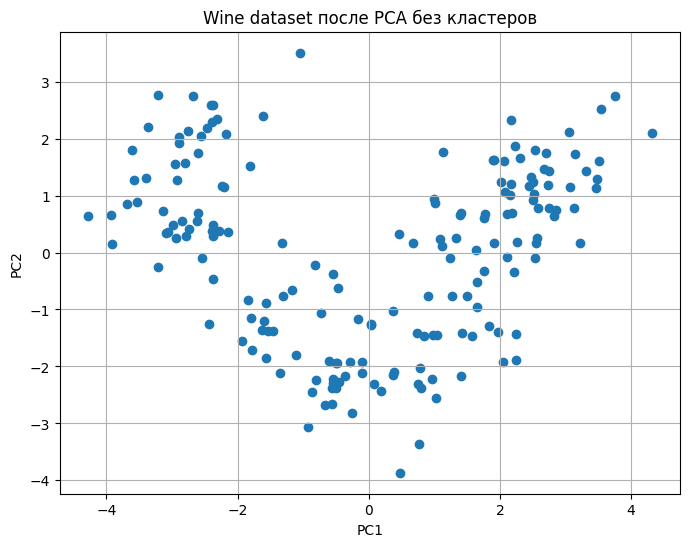

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Доля объяснённой дисперсии PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Доля объяснённой дисперсии PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Итого 2 компоненты объясняют:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Wine dataset после PCA без кластеров')
plt.grid(True)
plt.show()

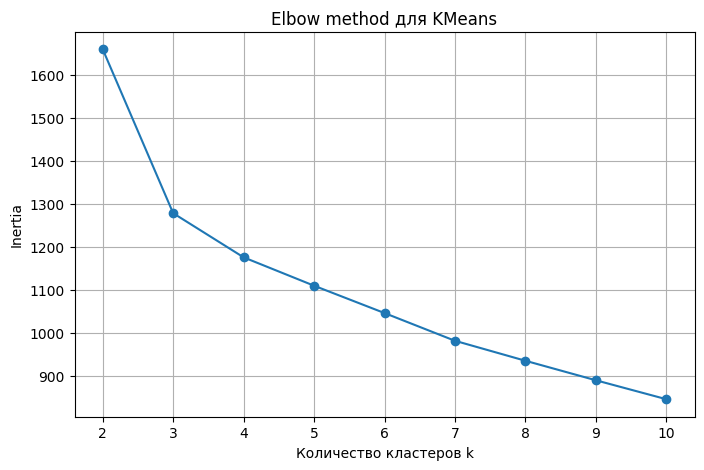

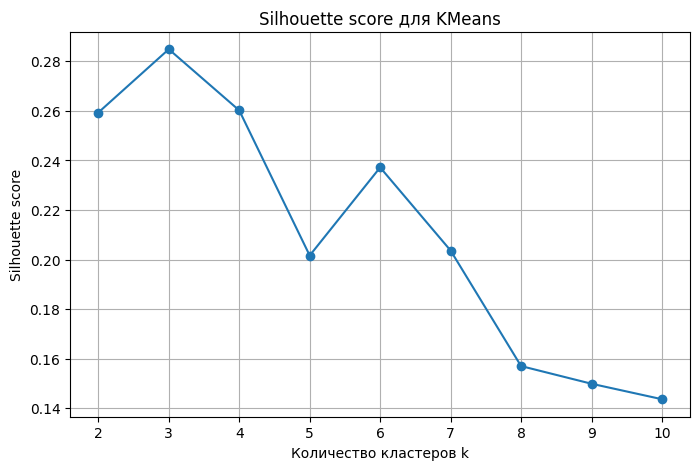

Лучшее k по silhouette: 3


In [5]:
inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia')
plt.title('Elbow method для KMeans')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouettes, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score для KMeans')
plt.grid(True)
plt.show()

best_k = list(k_values)[int(np.argmax(silhouettes))]
print("Лучшее k по silhouette:", best_k)

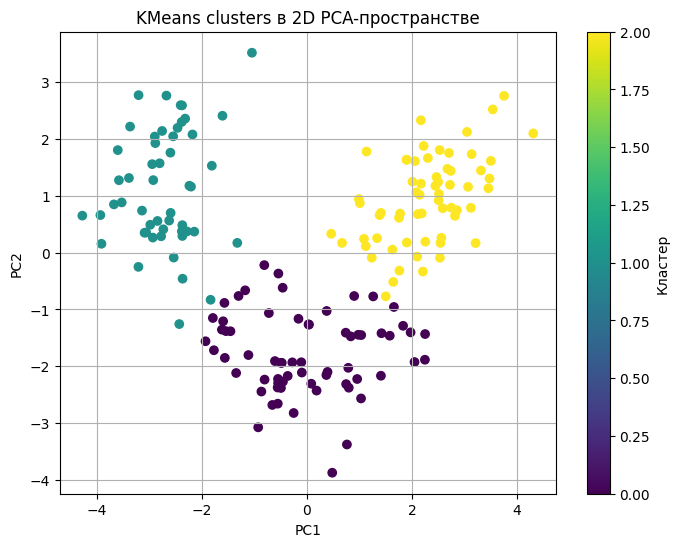

Размеры кластеров KMeans:


0    65
1    51
2    62
Name: count, dtype: int64

In [6]:
kmeans_k = 3

kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

pca_df['KMeans_cluster'] = kmeans_labels

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['KMeans_cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters в 2D PCA-пространстве')
plt.colorbar(label='Кластер')
plt.grid(True)
plt.show()

print("Размеры кластеров KMeans:")
display(pd.Series(kmeans_labels).value_counts().sort_index())

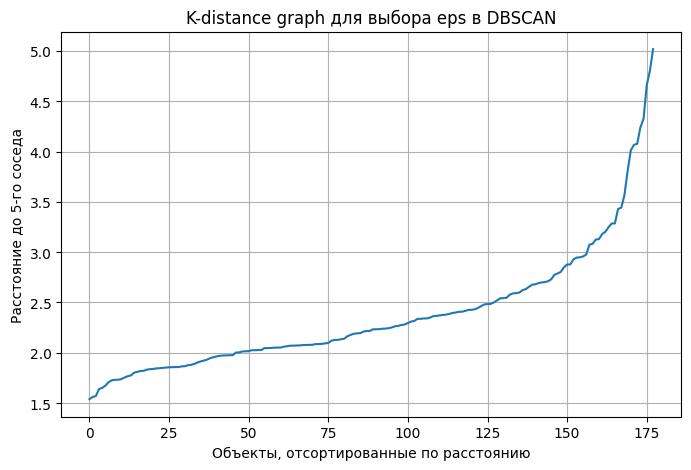

In [7]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Объекты, отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {min_samples}-го соседа')
plt.title('K-distance graph для выбора eps в DBSCAN')
plt.grid(True)
plt.show()

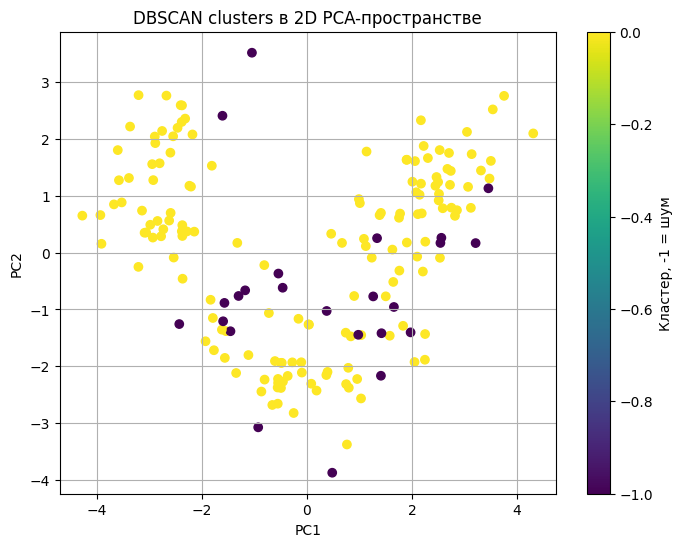

Размеры кластеров DBSCAN:


-1     24
 0    154
Name: count, dtype: int64

In [8]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

pca_df['DBSCAN_cluster'] = dbscan_labels

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['DBSCAN_cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN clusters в 2D PCA-пространстве')
plt.colorbar(label='Кластер, -1 = шум')
plt.grid(True)
plt.show()

print("Размеры кластеров DBSCAN:")
display(pd.Series(dbscan_labels).value_counts().sort_index())

In [9]:
def clustering_metrics(X, labels, name):
    labels = np.array(labels)
    mask = labels != -1
    unique_clusters = set(labels[mask])
    
    if len(unique_clusters) < 2:
        return {
            'algorithm': name,
            'clusters_without_noise': len(unique_clusters),
            'noise_points': int(np.sum(labels == -1)),
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }
    
    return {
        'algorithm': name,
        'clusters_without_noise': len(unique_clusters),
        'noise_points': int(np.sum(labels == -1)),
        'silhouette': silhouette_score(X[mask], labels[mask]),
        'davies_bouldin': davies_bouldin_score(X[mask], labels[mask]),
        'calinski_harabasz': calinski_harabasz_score(X[mask], labels[mask])
    }

metrics_df = pd.DataFrame([
    clustering_metrics(X_scaled, kmeans_labels, 'KMeans'),
    clustering_metrics(X_scaled, dbscan_labels, 'DBSCAN')
])

display(metrics_df)

,algorithm,clusters_without_noise,noise_points,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,3,0,0.284859,1.389188,70.940008
1,DBSCAN,1,24,NaN,NaN,NaN


In [10]:
result = numeric_data.copy()
result['KMeans_cluster'] = kmeans_labels
result['DBSCAN_cluster'] = dbscan_labels

print("Средние значения признаков по KMeans-кластерам:")
kmeans_profile = result.groupby('KMeans_cluster').mean().T
display(kmeans_profile)

print("Средние значения признаков по DBSCAN-кластерам:")
dbscan_profile = result.groupby('DBSCAN_cluster').mean().T
display(dbscan_profile)

Средние значения признаков по KMeans-кластерам:


KMeans_cluster,0,1,2
Alcohol,12.250923,13.134118,13.676774
Malic_Acid,1.897385,3.307255,1.997903
Ash,2.231231,2.417647,2.466290
Ash_Alcanity,20.063077,21.241176,17.462903
Magnesium,92.738462,98.666667,107.967742
Total_Phenols,2.247692,1.683922,2.847581
Flavanoids,2.050000,0.818824,3.003226
Nonflavanoid_Phenols,0.357692,0.451961,0.292097
Proanthocyanins,1.624154,1.145882,1.922097
Color_Intensity,2.973077,7.234706,5.453548


Средние значения признаков по DBSCAN-кластерам:


DBSCAN_cluster,-1,0
Alcohol,12.520417,13.075455
Malic_Acid,2.432083,2.321429
Ash,2.344583,2.369935
Ash_Alcanity,20.475000,19.342208
Magnesium,105.250000,98.883117
Total_Phenols,2.408750,2.277403
Flavanoids,2.213333,2.000584
Nonflavanoid_Phenols,0.365000,0.361364
Proanthocyanins,2.081667,1.514416
Color_Intensity,4.017917,5.220195


cluster,0,1,2,range_between_clusters
Flavanoids,0.020813,-1.215248,0.977820,2.193067
OD280,0.270764,-1.292412,0.779247,2.071659
Proline,-0.753846,-0.407088,1.125185,1.879031
Total_Phenols,-0.075983,-0.979330,0.885237,1.864568
Color_Intensity,-0.901914,0.941539,0.171063,1.843453
Alcohol,-0.926072,0.164907,0.835232,1.761304
Hue,0.461804,-1.164789,0.473984,1.638772
Proanthocyanins,0.058266,-0.779706,0.580287,1.359993


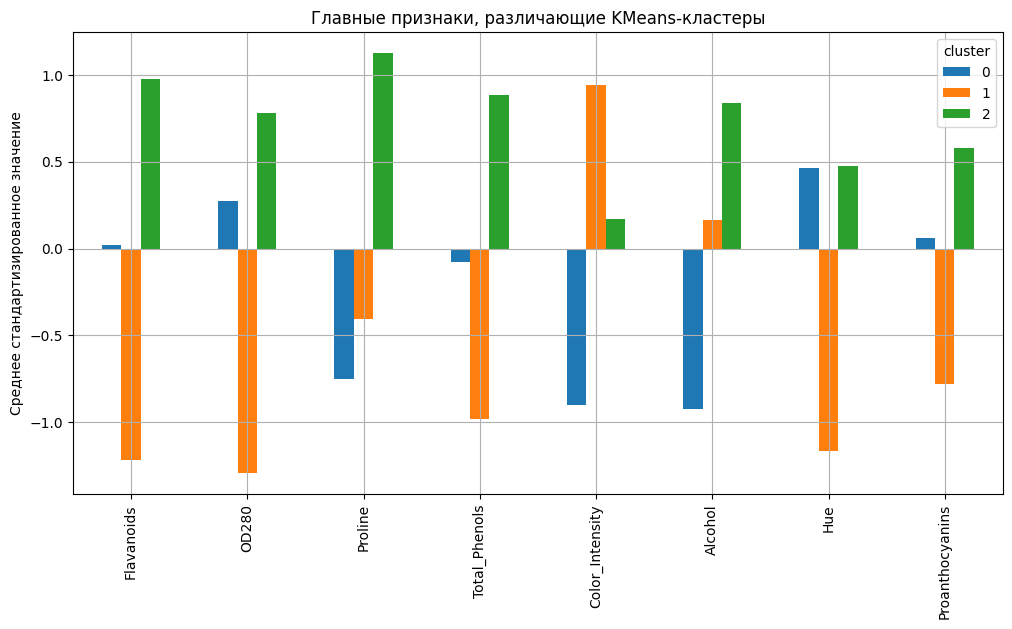

In [11]:
cluster_means_scaled = pd.DataFrame(X_scaled, columns=numeric_data.columns)
cluster_means_scaled['cluster'] = kmeans_labels

diff = cluster_means_scaled.groupby('cluster').mean().T
diff['range_between_clusters'] = diff.max(axis=1) - diff.min(axis=1)

top_features = diff.sort_values('range_between_clusters', ascending=False).head(8)
display(top_features)

top_features.drop(columns='range_between_clusters').plot(kind='bar', figsize=(12, 6))
plt.title('Главные признаки, различающие KMeans-кластеры')
plt.ylabel('Среднее стандартизированное значение')
plt.grid(True)
plt.show()